In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Calculating EVI from PlanetScope imagery


In [ ]:
import glob
import os

import numpy as np
import rasterio

# Input and output folders.

input_folder = r"/content/drive/MyDrive/Colab Notebooks/PlanetScope_Images"
output_folder = r"/content/drive/MyDrive/Colab Notebooks/EVI_Images"

os.makedirs(output_folder, exist_ok=True)

image_files = sorted(glob.glob(os.path.join(input_folder, "*.tif")))

print(f"{len(image_files)} images found.")

# Calculate EVI for each PlanetScope image.

for image_path in image_files:

    image_name = os.path.basename(image_path)

    print(f"Processing: {image_name}")

    with rasterio.open(image_path) as src:

        profile = src.profile.copy()

        # PlanetScope SuperDove bands
        blue = src.read(2).astype(np.float32)
        red = src.read(6).astype(np.float32)
        nir = src.read(8).astype(np.float32)

        # Convert DN to reflectance
        blue /= 10000.0
        red /= 10000.0
        nir /= 10000.0

        denominator = nir + 6 * red - 7.5 * blue + 1.0

        evi = np.where(
            denominator != 0,
            2.5 * (nir - red) / denominator,
            np.nan,
        )

        profile.update(
            dtype=rasterio.float32,
            count=1,
            nodata=np.nan,
        )

        output_path = os.path.join(output_folder, image_name)

        with rasterio.open(output_path, "w", **profile) as dst:
            dst.write(evi.astype(np.float32), 1)

print("\nFinished creating EVI images.")

#Extracting EVI values from PlanetScope imagery

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import rasterio

# ==========================================================
# Input paths
# ==========================================================

image_folder = r"/content/drive/MyDrive/Colab Notebooks/EVI_Images"

species_files = [
    (
        "Platanus",
        r"/content/drive/MyDrive/Colab Notebooks/Platanus_LST_4zones.csv",
        r"/content/drive/MyDrive/Colab Notebooks/Platanus_EVI_Timeseries.csv",
    ),
    (
        "Celtis",
        r"/content/drive/MyDrive/Colab Notebooks/Celtis_LST_4zones.csv",
        r"/content/drive/MyDrive/Colab Notebooks/Celtis_EVI_Timeseries.csv",
    ),
    (
        "Japonicum",
        r"/content/drive/MyDrive/Colab Notebooks/Japonicum_LST_4zones.csv",
        r"/content/drive/MyDrive/Colab Notebooks/Japonicum_EVI_Timeseries.csv",
    ),
]

# ==========================================================
# Find all EVI images
# ==========================================================

image_files = sorted(glob.glob(os.path.join(image_folder, "*.tif")))

print(f"{len(image_files)} images found.")

# ==========================================================
# Extract the EVI time series
# ==========================================================

for species, input_csv, output_csv in species_files:

    print(f"\nProcessing {species}...")

    trees = pd.read_csv(input_csv)

    coordinates = list(
        zip(
            trees["x_etrs89"],
            trees["y_etrs89"]
        )
    )

    for image_path in image_files:

        image_name = os.path.splitext(
            os.path.basename(image_path)
        )[0]

        print(f"   {image_name}")

        with rasterio.open(image_path) as src:

            values = [
                value[0] if not np.isnan(value[0]) else np.nan
                for value in src.sample(coordinates)
            ]

        trees[image_name] = values

    trees.to_csv(output_csv, index=False)

    print(f"Saved: {output_csv}")

print("\nFinished processing all species.")

#*K-Means* Clustering based on LST mean for three different trees

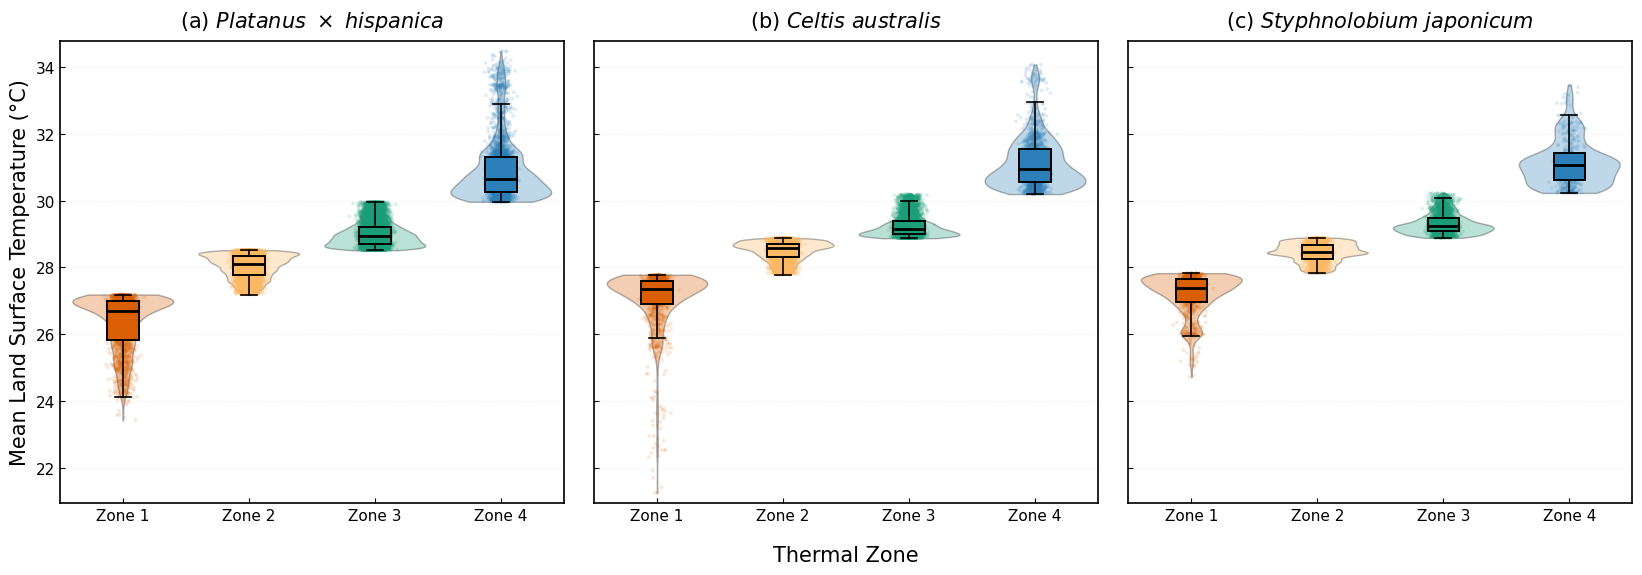

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the LST datasets.

platanus = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Platanus_LST_4zones.csv")
celtis = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Celtis_LST_4zones.csv")
japonicum = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Japonicum_LST_4zones.csv")

datasets = [
    (r"(a) $\it{Platanus\ \times\ hispanica}$", platanus),
    (r"(b) $\it{Celtis\ australis}$", celtis),
    (r"(c) $\it{Styphnolobium\ japonicum}$", japonicum),
]

# Configure the publication-style figure.

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.linewidth": 1.2,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

colors = [
    "#d95f02",
    "#fdb863",
    "#1b9e77",
    "#2c7fb8",
]

all_values = pd.concat([
    platanus["Mean_LST"],
    celtis["Mean_LST"],
    japonicum["Mean_LST"],
])

ymin = all_values.min() - 0.3
ymax = all_values.max() + 0.3

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 6),
    sharey=True,
)

# Create the raincloud plots.

for ax, (title, df) in zip(axes, datasets):

    data = [
        df[df["LST_zone"] == 1]["Mean_LST"],
        df[df["LST_zone"] == 2]["Mean_LST"],
        df[df["LST_zone"] == 3]["Mean_LST"],
        df[df["LST_zone"] == 4]["Mean_LST"],
    ]

    vp = ax.violinplot(
        data,
        positions=[1, 2, 3, 4],
        widths=0.8,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for body, color in zip(vp["bodies"], colors):
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.30)

    bp = ax.boxplot(
        data,
        positions=[1, 2, 3, 4],
        widths=0.25,
        patch_artist=True,
        showfliers=False,
    )

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor("black")
        patch.set_linewidth(1.4)

    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(2)

    for whisker in bp["whiskers"]:
        whisker.set_linewidth(1.2)

    for cap in bp["caps"]:
        cap.set_linewidth(1.2)

    np.random.seed(42)

    for i, zone in enumerate([1, 2, 3, 4], start=1):

        y = df[df["LST_zone"] == zone]["Mean_LST"]
        x = np.random.normal(i, 0.045, len(y))

        ax.scatter(
            x,
            y,
            s=7,
            alpha=0.15,
            color=colors[i - 1],
            edgecolor="none",
            rasterized=True,
        )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="normal",
        pad=10,
    )

    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(["Zone 1", "Zone 2", "Zone 3", "Zone 4"])

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.6,
        alpha=0.12,
    )

    ax.set_ylim(ymin, ymax)

axes[0].set_ylabel(
    "Mean Land Surface Temperature (°C)",
    fontsize=15,
)

axes[1].set_xlabel(
    "Thermal Zone",
    fontsize=15,
    labelpad=16,
)

# Save the figure.

plt.subplots_adjust(
    left=0.07,
    right=0.995,
    top=0.90,
    bottom=0.13,
    wspace=0.06,
)

plt.savefig(
    "Raincloud_ThermalZones_Publication.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

#Double Logistic Curves for Three Tree Species

<class 'pandas.core.frame.DataFrame'>
                                  Species  Zone  \
0  (a) $\it{Platanus\ \times\ hispanica}$     1   
1  (a) $\it{Platanus\ \times\ hispanica}$     4   
2            (b) $\it{Celtis\ australis}$     1   
3            (b) $\it{Celtis\ australis}$     4   
4     (c) $\it{Styphnolobium\ japonicum}$     1   

                                       Observed_Days  \
0  [0.0, 2.0, 2.9999999999999996, 7.0, 10.0, 11.0...   
1  [0.0, 2.0, 2.9999999999999996, 7.0, 10.0, 11.0...   
2  [0.0, 2.0, 2.9999999999999996, 7.0, 10.0, 11.0...   
3  [0.0, 2.0, 2.9999999999999996, 7.0, 10.0, 11.0...   
4  [0.0, 2.0, 2.9999999999999996, 7.0, 10.0, 11.0...   

                                        Observed_EVI  \
0  [0.13328453398645493, 0.13731591575030358, 0.1...   
1  [0.1273393518366465, 0.13470387080815327, 0.13...   
2  [0.1115728675307985, 0.11964093760988594, 0.11...   
3  [0.09443645234832172, 0.10289763686700443, 0.1...   
4  [0.10152041254825463, 0.10989633244

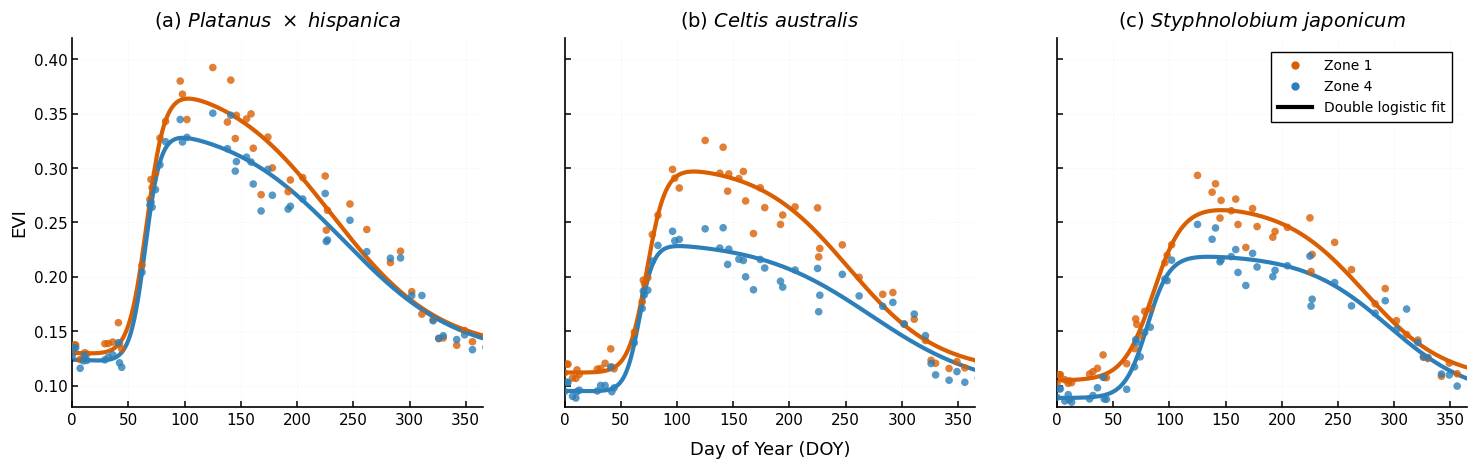

In [ ]:
# ============================================================
# PART 1
# Publication-quality Double Logistic Curves
# Three Species
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from matplotlib.lines import Line2D

# ============================================================
# Publication Settings
# ============================================================

plt.rcParams.update({

    "font.family": "DejaVu Sans",      # Set the writing format

    "font.size": 11,

    "axes.labelsize": 14,

    "axes.titlesize": 15,

    "axes.linewidth": 1.2,

    "xtick.labelsize": 11,

    "ytick.labelsize": 11,

    "legend.fontsize": 11,

    "xtick.direction": "in",

    "ytick.direction": "in"

})

# ============================================================
# File paths
# ============================================================

files = [

    (
        "/content/drive/MyDrive/Colab Notebooks/Platanus_EVI_Timeseries.csv",
        r"(a) $\it{Platanus\ \times\ hispanica}$"
    ),

    (
        "/content/drive/MyDrive/Colab Notebooks/Celtis_EVI_Timeseries.csv",
        r"(b) $\it{Celtis\ australis}$"
    ),

    (
        "/content/drive/MyDrive/Colab Notebooks/Journal/Japonicum_EVI_Timeseries.csv",
        r"(c) $\it{Styphnolobium\ japonicum}$"
    )

]

# ============================================================
# Publication colours
# ============================================================

colors = {

    1: "#d95f02",      # Zone 1

    4: "#2c7fb8"       # Zone 4

}

# ============================================================
# Helper function
# Automatically detect EVI columns
# ============================================================

def load_species(filepath):

    df = pd.read_csv(filepath)

    # ------------------------------------
    # Find all date columns automatically
    # ------------------------------------

    evi_columns = [

        col

        for col in df.columns

        if str(col).isdigit()

    ]

    grouped = (

        df

        .groupby("LST_zone")[evi_columns]

        .mean()

        .loc[[1,4]]

    )

    dates = pd.to_datetime(

        evi_columns,

        format="%Y%m%d"

    )

    t = (

        (dates - dates.min()).days.values

        / 365.0

    )

    return grouped, t

# ============================================================
# Determine common y-axis
# ============================================================

global_min = 999

global_max = -999

for filepath, _ in files:

    grouped, _ = load_species(filepath)

    ymin = np.nanmin(grouped.values)

    ymax = np.nanmax(grouped.values)

    global_min = min(global_min, ymin)

    global_max = max(global_max, ymax)

global_min -= 0.03

global_max += 0.03
# ============================================================
# PART 2
# Double Logistic Model
# ============================================================

def double_logistic(t, w, m, S, A, k1, k2):

    spring = 1.0 / (1.0 + np.exp(-k1 * (t - S)))

    autumn = 1.0 / (1.0 + np.exp(k2 * (t - A)))

    return w + (m - w) * (spring + autumn - 1.0)


# ============================================================
# Robust Double Logistic Curve Fitting
# ============================================================

def fit_double_logistic(t, y):

    y = np.asarray(y, dtype=np.float64)

    # ----------------------------------------
    # Remove missing values
    # ----------------------------------------

    valid = np.isfinite(y)

    t_fit = t[valid]

    y_fit = y[valid]

    # ----------------------------------------
    # Initial parameter guess
    # ----------------------------------------

    p0 = [

        np.min(y_fit),

        np.max(y_fit),

        0.25,

        0.75,

        20,

        20

    ]

    lower = [

        0.00,

        0.05,

        0.05,

        0.40,

        1,

        1

    ]

    upper = [

        0.60,

        0.90,

        0.50,

        1.10,

        100,

        100

    ]

    # ----------------------------------------
    # First fitting
    # ----------------------------------------

    params, _ = curve_fit(

        double_logistic,

        t_fit,

        y_fit,

        p0=p0,

        bounds=(lower, upper),

        maxfev=50000

    )

    # ----------------------------------------
    # Robust weighted fitting
    # ----------------------------------------

    residuals = y_fit - double_logistic(t_fit, *params)

    sigma = np.abs(residuals) + 0.003

    params, _ = curve_fit(

        double_logistic,

        t_fit,

        y_fit,

        p0=params,

        sigma=sigma,

        absolute_sigma=False,

        bounds=(lower, upper),

        maxfev=50000

    )

    return params


# ============================================================
# Smooth Curve
# ============================================================

def create_smooth_curve(params, t):

    t_smooth = np.linspace(

        t.min(),

        t.max(),

        1000

    )

    y_smooth = double_logistic(

        t_smooth,

        *params

    )

    return t_smooth, y_smooth
# ============================================================
# PART 3
# Plot Each Species (Updated Version)
# ============================================================

fig, axes = plt.subplots(

    nrows=1,

    ncols=3,

    figsize=(18,4.8),

    sharex=True,

    sharey=True

)
curve_results = []
for ax, (filepath, title) in zip(axes, files):

    # ========================================================
    # Load species data
    # ========================================================

    grouped, t = load_species(filepath)

    # ========================================================
    # Smooth curve
    # ========================================================

    t_smooth = np.linspace(

        0,

        1,

        1200

    )

    # ========================================================
    # Plot Zone 1 and Zone 4
    # ========================================================

    for zone in [1,4]:

        y = grouped.loc[zone].values.astype(float)

        params = fit_double_logistic(t, y)

        y_smooth = double_logistic(

            t_smooth,

            *params

        )
        curve_results.append({

            "Species": title,
            "Zone": zone,
            "Observed_Days": t * 365,
            "Observed_EVI": y,
            "Smooth_Days": t_smooth * 365,
            "Smooth_EVI": y_smooth,
             "Parameters": params

        })



        # ------------------------------------------
        # Observed EVI
        # ------------------------------------------

        ax.scatter(

            t*365,

            y,

            s=30,

            color=colors[zone],

            edgecolor="none",

            alpha=0.80,

            zorder=3

        )

        # ------------------------------------------
        # Double Logistic Curve
        # ------------------------------------------

        ax.plot(

            t_smooth*365,

            y_smooth,

            color=colors[zone],

            linewidth=3.0,

            solid_capstyle="round",

            zorder=2

        )

    # ========================================================
    # Legend (only first subplot)
    # ========================================================

      # ========================================================
    # Legend (Only in Japonicum panel)
    # ========================================================

    if ax == axes[2]:

        legend_elements = [

            # Zone 1
            Line2D(
                [0], [0],
                marker='o',
                linestyle='None',
                markerfacecolor=colors[1],
                markeredgecolor='none',
                markersize=6,
                label='Zone 1'
            ),

            # Zone 4
            Line2D(
                [0], [0],
                marker='o',
                linestyle='None',
                markerfacecolor=colors[4],
                markeredgecolor='none',
                markersize=6,
                label='Zone 4'
            ),

            # Double Logistic Curve
            Line2D(
                [0], [0],
                color='black',
                linewidth=3,
                label='Double logistic fit'
            )

        ]

        ax.legend(

            handles=legend_elements,

            loc="upper right",

            bbox_to_anchor=(0.98, 0.98),

            fontsize=10,

            frameon=True,

            facecolor="white",

            edgecolor="black",

            framealpha=1,

            fancybox=False,

            handlelength=2.5,

            handletextpad=0.8,

            borderpad=0.5,

            labelspacing=0.5

        )
    # ========================================================
    # Formatting
    # ========================================================

    ax.set_title(

        title,

        fontsize=14,

        fontweight="normal",

        pad=8

    )

    ax.set_xlim(

        0,

        365

    )

    ax.set_ylim(

        0.08,

        0.42

    )

    ax.set_xticks(

        [0,50,100,150,200,250,300,350]

    )

    ax.set_yticks(

        np.arange(0.10,0.41,0.05)

    )

    ax.tick_params(

        axis="both",

        width=1.1,

        length=4,

        labelsize=11

    )

    ax.grid(

        linestyle="--",

        linewidth=0.5,

        alpha=0.12

    )

    ax.spines["top"].set_visible(False)

    ax.spines["right"].set_visible(False)

# ============================================================
# Common Labels
# ============================================================

axes[0].set_ylabel(

    "EVI",

    fontsize=13,

    fontweight="normal"

)

axes[1].set_xlabel(

    "Day of Year (DOY)",

    fontsize=13,

    fontweight="normal",

    labelpad=10

)
# ============================================================
# Save fitted curves
# ============================================================

curve_results = pd.DataFrame(curve_results)

print(type(curve_results))
print(curve_results.head())

# Extract and Visualize Land Surface Phenology (LSP) Metrics using 20% threshold

                                  Species  Zone    SOS     POS     EOS     LOS
0  (a) $\it{Platanus\ \times\ hispanica}$     1  55.40  103.20  303.81  248.41
1  (a) $\it{Platanus\ \times\ hispanica}$     4  55.71   98.33  319.95  264.24
2            (b) $\it{Celtis\ australis}$     1  61.80  114.77  310.51  248.71
3            (b) $\it{Celtis\ australis}$     4  57.84  101.68  345.82  287.98
4     (c) $\it{Styphnolobium\ japonicum}$     1  66.97  146.12  324.82  257.84
5     (c) $\it{Styphnolobium\ japonicum}$     4  66.67  135.16  347.65  280.98
                                  Species  Zone  SOS_DOY  POS_DOY  EOS_DOY  \
0  (a) $\it{Platanus\ \times\ hispanica}$     1       87      135      335   
1  (a) $\it{Platanus\ \times\ hispanica}$     4       87      130      351   
2            (b) $\it{Celtis\ australis}$     1       93      146      342   
3            (b) $\it{Celtis\ australis}$     4       89      133       11   
4     (c) $\it{Styphnolobium\ japonicum}$     1       98 

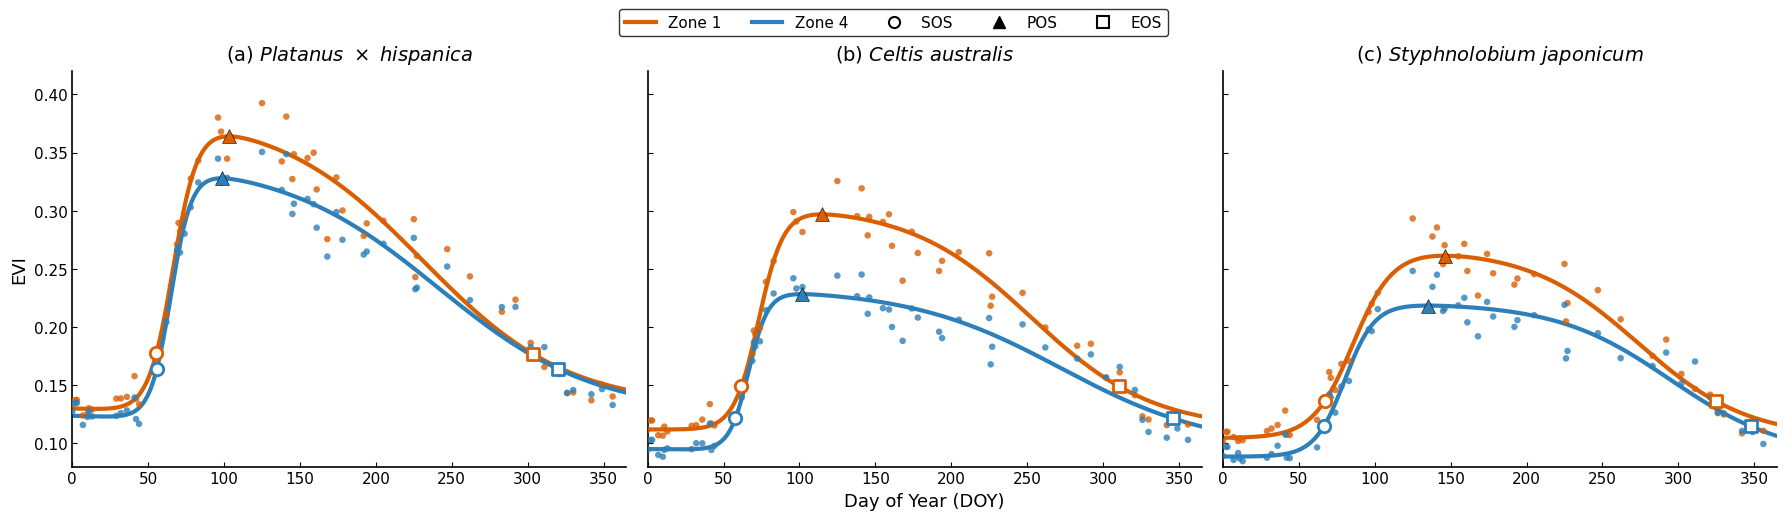

In [ ]:
# Extract LSP metrics from the fitted curves.

lsp_results = []

for _, curve in curve_results.iterrows():
    species = curve["Species"]
    zone = curve["Zone"]
    days = np.array(curve["Smooth_Days"])
    y_smooth = np.array(curve["Smooth_EVI"])
    y = np.array(curve["Observed_EVI"])

    # Calculate the 20% dynamic threshold.
    evi_min = y_smooth.min()
    evi_max = y_smooth.max()
    threshold = evi_min + 0.20 * (evi_max - evi_min)

    pos_idx = np.argmax(y_smooth)
    sos_idx = np.where(y_smooth >= threshold)[0][0]
    eos_idx = np.where(y_smooth >= threshold)[0][-1]

    lsp_results.append({
        "Species": species,
        "Zone": zone,
        "SOS": days[sos_idx],
        "POS": days[pos_idx],
        "EOS": days[eos_idx],
        "LOS": days[eos_idx] - days[sos_idx],
        "Threshold": threshold,
        "Curve_Days": days,
        "Curve_EVI": y_smooth,
        "Observed_EVI": y,
        "SOS_Day": days[sos_idx],
        "SOS_EVI": y_smooth[sos_idx],
        "POS_Day": days[pos_idx],
        "POS_EVI": y_smooth[pos_idx],
        "EOS_Day": days[eos_idx],
        "EOS_EVI": y_smooth[eos_idx],
    })

lsp_results = pd.DataFrame(lsp_results)

print(lsp_results[["Species", "Zone", "SOS", "POS", "EOS", "LOS"]].round(2))


# Create the final LSP summary table.

from datetime import timedelta

first_date = pd.Timestamp("2024-02-01")
final_table = []

for _, row in lsp_results.iterrows():
    sos_date = first_date + timedelta(days=float(row["SOS"]))
    pos_date = first_date + timedelta(days=float(row["POS"]))
    eos_date = first_date + timedelta(days=float(row["EOS"]))

    final_table.append({
        "Species": row["Species"],
        "Zone": row["Zone"],
        "SOS_DOY": sos_date.dayofyear,
        "POS_DOY": pos_date.dayofyear,
        "EOS_DOY": eos_date.dayofyear,
        "LOS_days": round(row["LOS"], 1),
    })

final_table = pd.DataFrame(final_table)
print(final_table)


# Plot the extracted LSP metrics.

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax, (filepath, title) in zip(axes, files):
    species_data = lsp_results[lsp_results["Species"] == title]

    for _, row in species_data.iterrows():
        zone = row["Zone"]

        observed = curve_results[
            (curve_results["Species"] == title) &
            (curve_results["Zone"] == zone)
        ].iloc[0]

        ax.scatter(
            observed["Observed_Days"], row["Observed_EVI"],
            s=22, color=colors[zone], edgecolor="none",
            alpha=0.8, zorder=3
        )

        ax.plot(
            row["Curve_Days"], row["Curve_EVI"],
            color=colors[zone], linewidth=3,
            solid_capstyle="round", zorder=2
        )

        ax.scatter(row["SOS_Day"], row["SOS_EVI"], marker="o",
                   s=80, facecolors="white", edgecolors=colors[zone],
                   linewidth=2, zorder=6)

        ax.scatter(row["POS_Day"], row["POS_EVI"], marker="^",
                   s=100, color=colors[zone], edgecolor="black",
                   linewidth=0.4, zorder=6)

        ax.scatter(row["EOS_Day"], row["EOS_EVI"], marker="s",
                   s=80, facecolors="white", edgecolors=colors[zone],
                   linewidth=2, zorder=6)

    ax.set_title(title, fontsize=14, pad=8)
    ax.set_xlim(0, 365)
    ax.set_ylim(0.08, 0.42)
    ax.set_xticks([0, 50, 100, 150, 200, 250, 300, 350])
    ax.set_yticks(np.arange(0.10, 0.41, 0.05))
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("EVI", fontsize=13)
axes[1].set_xlabel("Day of Year (DOY)", fontsize=13)

legend = [
    Line2D([0], [0], color=colors[1], lw=3, label="Zone 1"),
    Line2D([0], [0], color=colors[4], lw=3, label="Zone 4"),
    Line2D([0], [0], marker="o", linestyle="None",
           markerfacecolor="white", markeredgecolor="black",
           markeredgewidth=1.5, markersize=8, label="SOS"),
    Line2D([0], [0], marker="^", linestyle="None",
           markerfacecolor="black", markeredgecolor="black",
           markersize=9, label="POS"),
    Line2D([0], [0], marker="s", linestyle="None",
           markerfacecolor="white", markeredgecolor="black",
           markeredgewidth=1.5, markersize=8, label="EOS"),
]

fig.legend(handles=legend, loc="upper center",
           bbox_to_anchor=(0.5, 1.05), ncol=5,
           frameon=True, edgecolor="black")

plt.tight_layout()
plt.show()


# Validation of LSP Metrics

In [ ]:

# ============================================================

validation = []

for _, row in lsp_results.iterrows():

    # Expected threshold
    threshold = row["Threshold"]

    # EVI at extracted SOS and EOS
    sos_evi = row["SOS_EVI"]
    eos_evi = row["EOS_EVI"]

    validation.append({

        "Species": row["Species"],

        "Zone": row["Zone"],

        "Threshold": threshold,

        "SOS_EVI": sos_evi,

        "EOS_EVI": eos_evi,

        "SOS_Error": abs(sos_evi - threshold),

        "EOS_Error": abs(eos_evi - threshold)

    })

validation = pd.DataFrame(validation)

print(validation.round(5))

                                  Species  Zone  Threshold  SOS_EVI  EOS_EVI  \
0  (a) $\it{Platanus\ \times\ hispanica}$     1    0.17646  0.17738  0.17654   
1  (a) $\it{Platanus\ \times\ hispanica}$     4    0.16399  0.16400  0.16406   
2            (b) $\it{Celtis\ australis}$     1    0.14892  0.14913  0.14894   
3            (b) $\it{Celtis\ australis}$     4    0.12152  0.12156  0.12155   
4     (c) $\it{Styphnolobium\ japonicum}$     1    0.13605  0.13605  0.13623   
5     (c) $\it{Styphnolobium\ japonicum}$     4    0.11455  0.11512  0.11466   

   SOS_Error  EOS_Error  
0    0.00093    0.00009  
1    0.00001    0.00007  
2    0.00021    0.00002  
3    0.00003    0.00002  
4    0.00000    0.00019  
5    0.00057    0.00011  


#Extracting LSP metrics for individual trees for Mann - Whitney U Test

***Platanus x hispanica***

In [ ]:
# Load the input data.

import numpy as np
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/Platanus_EVI_Timeseries.csv"
)

# Prepare the EVI time series.

evi_columns = [col for col in df.columns if col.isdigit()]
dates = pd.to_datetime(evi_columns, format="%Y%m%d")
elapsed_days = (dates - dates.min()).days.values
t = elapsed_days / elapsed_days.max()

# Extract LSP metrics for each tree.

tree_results = []

for _, row in df.iterrows():

    try:
        tree_id = row["codi"]
        zone = row["LST_zone"]
        y = row[evi_columns].values.astype(float)

        # Skip trees with too many missing values.
        mask = np.isfinite(y)
        if mask.sum() < 10:
            continue

        t_fit = t[mask]
        y_fit = y[mask]

        # Fit the double logistic model.
        params = fit_double_logistic(t_fit, y_fit)

        t_smooth = np.linspace(0, 1, 1200)
        y_smooth = double_logistic(t_smooth, *params)
        days = t_smooth * 365

        # Calculate the 20% dynamic threshold.
        threshold = (
            y_smooth.min()
            + 0.20 * (y_smooth.max() - y_smooth.min())
        )

        pos_idx = np.argmax(y_smooth)
        sos_idx = np.where(y_smooth >= threshold)[0][0]
        eos_idx = np.where(y_smooth >= threshold)[0][-1]

        tree_results.append({
            "codi": tree_id,
            "LST_zone": zone,
            "SOS": days[sos_idx],
            "POS": days[pos_idx],
            "EOS": days[eos_idx],
            "GSL": days[eos_idx] - days[sos_idx],
        })

    except Exception:
        continue

# Save the results.

tree_results = pd.DataFrame(tree_results)

print(tree_results.head())

print(f"\nSuccessful trees: {len(tree_results)}")
print(f"Failed trees: {len(df) - len(tree_results)}")

tree_results.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/Platanus_LSP_Tree.csv",
    index=False
)

        codi  LST_zone        SOS         POS         EOS         GSL
0  0019317AR         1  51.142619  120.246038  289.808173  238.665555
1  0019319AR         1  57.231026  100.458716  298.027523  240.796497
2  0019346AR         1  62.406172  108.678065  289.808173  227.402002
3  0019380AR         1  70.625521  121.159299  259.974979  189.349458
4  0019384AR         1  50.838198  128.160967  271.847373  221.009174

Successful trees: 5541
Failed trees: 71


***Celtis Australis***

In [ ]:
# Load the species time series.

import numpy as np
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Celtis_EVI_Timeseries.csv")

# Remove the BOM character if it exists.
df.columns = df.columns.str.replace("ï»¿", "", regex=False)

# Prepare the EVI time series.

evi_columns = [col for col in df.columns if col.isdigit()]
dates = pd.to_datetime(evi_columns, format="%Y%m%d")
elapsed_days = (dates - dates.min()).days.values
t = elapsed_days / elapsed_days.max()

# Extract LSP metrics for each tree.

tree_results = []

for _, row in df.iterrows():

    tree_id = row["codi"]
    zone = row["LST_zone"]
    y = row[evi_columns].astype(float).values

    # Skip trees with too many missing values.
    if np.isfinite(y).sum() < 20:
        continue

    try:
        params = fit_double_logistic(t, y)

        t_smooth = np.linspace(0, 1, 2000)
        y_smooth = double_logistic(t_smooth, *params)

    except Exception:
        continue

    days = t_smooth * elapsed_days.max()

    # Calculate the 20% dynamic threshold.
    threshold = y_smooth.min() + 0.20 * (y_smooth.max() - y_smooth.min())

    pos_idx = np.argmax(y_smooth)

    before = np.arange(pos_idx)
    after = np.arange(pos_idx, len(y_smooth))

    sos_idx = before[np.where(y_smooth[before] >= threshold)[0][0]]
    eos_idx = after[np.where(y_smooth[after] >= threshold)[0][-1]]

    tree_results.append({
        "codi": tree_id,
        "LST_zone": zone,
        "SOS": days[sos_idx],
        "POS": days[pos_idx],
        "EOS": days[eos_idx],
        "GSL": days[eos_idx] - days[sos_idx],
    })

# Save the results.

tree_results = pd.DataFrame(tree_results)

print(tree_results.head())
print(f"\nSuccessful trees: {len(tree_results)}")
print(f"Failed trees: {len(df) - len(tree_results)}")

tree_results.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/Celtis_LSP_Tree.csv",
    index=False,
)

        codi  LST_zone        SOS         POS         EOS         GSL
0  0017256AR         1  73.666833  109.204602  362.041021  288.374187
1  0019304AR         1  66.448224  133.081541  265.977989  199.529765
2  0019305AR         1  70.520260  106.798399  321.875938  251.355678
3  0019306AR         1  65.707854  104.392196  278.194097  212.486243
4  0019315AR         1  73.666833  105.872936  309.659830  235.992996

Successful trees: 2832
Failed trees: 62


***Styphnolobium japonicum***

In [ ]:
# Load the input data.

import numpy as np
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/Japonicum_EVI_Timeseries.csv"
)

# Remove the BOM character if it exists.
df.columns = df.columns.str.replace("ï»¿", "", regex=False)

# Prepare the EVI time series.

evi_columns = [col for col in df.columns if col.isdigit()]
dates = pd.to_datetime(evi_columns, format="%Y%m%d")
elapsed_days = (dates - dates.min()).days.values
t = elapsed_days / elapsed_days.max()

# Extract LSP metrics for each tree.

tree_results = []

for _, row in df.iterrows():

    tree_id = row["codi"]
    zone = row["LST_zone"]
    y = row[evi_columns].astype(float).values

    # Skip trees with too many missing values.
    if np.isfinite(y).sum() < 20:
        continue

    try:
        params = fit_double_logistic(t, y)

        t_smooth = np.linspace(0, 1, 2000)
        y_smooth = double_logistic(t_smooth, *params)

    except Exception:
        continue

    days = t_smooth * elapsed_days.max()

    # Calculate the 20% dynamic threshold.
    threshold = (
        y_smooth.min()
        + 0.20 * (y_smooth.max() - y_smooth.min())
    )

    pos_idx = np.argmax(y_smooth)

    before = np.arange(pos_idx)
    after = np.arange(pos_idx, len(y_smooth))

    sos_idx = before[np.where(y_smooth[before] >= threshold)[0][0]]
    eos_idx = after[np.where(y_smooth[after] >= threshold)[0][-1]]

    tree_results.append({
        "codi": tree_id,
        "LST_zone": zone,
        "SOS": days[sos_idx],
        "POS": days[pos_idx],
        "EOS": days[eos_idx],
        "GSL": days[eos_idx] - days[sos_idx],
    })

# Save the results.

tree_results = pd.DataFrame(tree_results)

print(tree_results.head())

print(f"\nSuccessful trees: {len(tree_results)}")
print(f"Failed trees: {len(df) - len(tree_results)}")

tree_results.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/Japonicum_LSP_Tree.csv",
    index=False
)

        codi  LST_zone        SOS         POS         EOS         GSL
0  0019520AR         1  62.006003  173.801901  328.539270  266.533267
1  0019612AR         1  65.337669   99.579790  229.699850  164.362181
2  0019804AR         1  58.489245  122.531266  244.137069  185.647824
3  0020134AR         1  62.561281   95.877939  245.987994  183.426713
4  0020725AR         1  71.630815  149.554777  293.926963  222.296148

Successful trees: 1466
Failed trees: 29


**Mann Whitney U Test**

In [ ]:
# Load the individual tree LSP datasets.

import pandas as pd
from scipy.stats import mannwhitneyu

files = [
    (
        "/content/drive/MyDrive/Colab Notebooks/Platanus_LSP_Tree.csv",
        r"(a) $\it{Platanus\ \times\ hispanica}$",
    ),
    (
        "/content/drive/MyDrive/Colab Notebooks/Celtis_LSP_Tree.csv",
        r"(b) $\it{Celtis\ australis}$",
    ),
    (
        "/content/drive/MyDrive/Colab Notebooks/Japonicum_LSP_Tree.csv",
        r"(c) $\it{Styphnolobium\ japonicum}$",
    ),
]

metrics = ["SOS", "POS", "EOS", "GSL"]

results = []

# Compare LSP metrics between Zone 1 and Zone 4.

for file_path, species in files:

    df = pd.read_csv(file_path)

    for metric in metrics:

        zone1 = df.loc[df["LST_zone"] == 1, metric].dropna()
        zone4 = df.loc[df["LST_zone"] == 4, metric].dropna()

        U, p = mannwhitneyu(
            zone1,
            zone4,
            alternative="two-sided",
        )

        z1_median = zone1.median()
        z1_q1 = zone1.quantile(0.25)
        z1_q3 = zone1.quantile(0.75)

        z4_median = zone4.median()
        z4_q1 = zone4.quantile(0.25)
        z4_q3 = zone4.quantile(0.75)

        if p < 0.001:
            sig = "***"
        elif p < 0.01:
            sig = "**"
        elif p < 0.05:
            sig = "*"
        else:
            sig = "ns"

        results.append({
            "Species": species,
            "Metric": metric,
            "Zone 1 (Median [IQR])":
                f"{z1_median:.2f} ({z1_q1:.2f}–{z1_q3:.2f})",
            "Zone 4 (Median [IQR])":
                f"{z4_median:.2f} ({z4_q1:.2f}–{z4_q3:.2f})",
            "U statistic": round(U, 2),
            "p-value": p,
            "Significance": sig,
        })

# Save the Mann–Whitney U test results.

results = pd.DataFrame(results)

results["p-value"] = results["p-value"].apply(
    lambda p: "<0.001" if p < 0.001 else f"{p:.4f}"
)

print(results)

results.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/Mann_Whitney_U_Results.csv",
    index=False,
)

print("\nMann_Whitney_U_Results.csv saved successfully.")

                                   Species Metric   Zone 1 (Median [IQR])  \
0   (a) $\it{Platanus\ \times\ hispanica}$    SOS     55.10 (49.62–58.75)   
1   (a) $\it{Platanus\ \times\ hispanica}$    POS   103.50 (97.11–113.24)   
2   (a) $\it{Platanus\ \times\ hispanica}$    EOS  300.77 (281.28–333.64)   
3   (a) $\it{Platanus\ \times\ hispanica}$    GSL  249.02 (230.75–277.63)   
4             (b) $\it{Celtis\ australis}$    SOS     65.52 (53.49–70.52)   
5             (b) $\it{Celtis\ australis}$    POS  118.46 (106.06–133.50)   
6             (b) $\it{Celtis\ australis}$    EOS  304.38 (277.27–339.55)   
7             (b) $\it{Celtis\ australis}$    GSL  246.73 (217.44–278.38)   
8      (c) $\it{Styphnolobium\ japonicum}$    SOS     69.22 (59.78–79.03)   
9      (c) $\it{Styphnolobium\ japonicum}$    POS  147.98 (134.61–173.25)   
10     (c) $\it{Styphnolobium\ japonicum}$    EOS  314.10 (290.13–339.23)   
11     (c) $\it{Styphnolobium\ japonicum}$    GSL  248.76 (222.48–270.37)   

#Shapiro–Wilk Normality Test

In [ ]:
# Load the individual tree LSP datasets.

import pandas as pd
from scipy.stats import shapiro

files = [
    (
        "/content/drive/MyDrive/Colab Notebooks/Platanus_LSP_Tree.csv",
        r"(a) $\it{Platanus\ \times\ hispanica}$",
    ),
    (
        "/content/drive/MyDrive/Colab Notebooks/Celtis_LSP_Tree.csv",
        r"(b) $\it{Celtis\ australis}$",
    ),
    (
        "/content/drive/MyDrive/Colab Notebooks/Japonicum_LSP_Tree.csv",
        r"(c) $\it{Styphnolobium\ japonicum}$",
    ),
]

metrics = ["SOS", "POS", "EOS", "GSL"]

normality_results = []

# Perform the Shapiro–Wilk normality test.

for file_path, species in files:

    df = pd.read_csv(file_path)

    for metric in metrics:

        statistic, p = shapiro(df[metric].dropna())

        normality_results.append({
            "Species": species,
            "Metric": metric,
            "W statistic": round(statistic, 4),
            "p-value": p,
            "Normal": "Yes" if p > 0.05 else "No",
        })

# Save the normality test results.

normality_results = pd.DataFrame(normality_results)

normality_results["p-value"] = normality_results["p-value"].apply(
    lambda p: "<0.001" if p < 0.001 else f"{p:.4f}"
)

print(normality_results)

normality_results.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/Shapiro_Wilk_Results.csv",
    index=False,
)

print("\nShapiro_Wilk_Results.csv saved successfully.")

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5541.
  res = hypotest_fun_out(*samples, **kwds)


                                   Species Metric  W statistic p-value Normal
0   (a) $\it{Platanus\ \times\ hispanica}$    SOS       0.7406  <0.001     No
1   (a) $\it{Platanus\ \times\ hispanica}$    POS       0.5403  <0.001     No
2   (a) $\it{Platanus\ \times\ hispanica}$    EOS       0.9503  <0.001     No
3   (a) $\it{Platanus\ \times\ hispanica}$    GSL       0.9745  <0.001     No
4             (b) $\it{Celtis\ australis}$    SOS       0.9120  <0.001     No
5             (b) $\it{Celtis\ australis}$    POS       0.7925  <0.001     No
6             (b) $\it{Celtis\ australis}$    EOS       0.9506  <0.001     No
7             (b) $\it{Celtis\ australis}$    GSL       0.9879  <0.001     No
8      (c) $\it{Styphnolobium\ japonicum}$    SOS       0.9493  <0.001     No
9      (c) $\it{Styphnolobium\ japonicum}$    POS       0.8632  <0.001     No
10     (c) $\it{Styphnolobium\ japonicum}$    EOS       0.9587  <0.001     No
11     (c) $\it{Styphnolobium\ japonicum}$    GSL       0.9949  

#Factorial Linear Model

In [ ]:
# Load the individual tree LSP datasets.

import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

p = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Platanus_LSP_Tree.csv")
c = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Celtis_LSP_Tree.csv")
j = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Japonicum_LSP_Tree.csv")

# Add species labels.

p["Species"] = "Platanus"
c["Species"] = "Celtis"
j["Species"] = "Styphnolobium"

# Combine the datasets.

data = pd.concat([p, c, j], ignore_index=True)

data["Species"] = data["Species"].astype("category")
data["LST_zone"] = data["LST_zone"].astype("category")

metrics = ["SOS", "POS", "EOS", "GSL"]

anova_results = []

# Test the effects of species, thermal zone, and their interaction.

for metric in metrics:

    model = smf.ols(
        f"{metric} ~ C(Species) * C(LST_zone)",
        data=data,
    ).fit()

    anova = anova_lm(model, typ=2)

    print(f"\n{'=' * 70}")
    print(f"{metric} ANOVA")
    print("=" * 70)
    print(anova)

    for effect in anova.index:

        anova_results.append({
            "Metric": metric,
            "Effect": effect,
            "DF": anova.loc[effect, "df"],
            "F": anova.loc[effect, "F"],
            "P_value": anova.loc[effect, "PR(>F)"],
        })

# Save the ANOVA results.

anova_results = pd.DataFrame(anova_results)

anova_results["P_value"] = anova_results["P_value"].apply(
    lambda p: "<0.001" if p < 0.001 else round(p, 4)
)

print(anova_results)

anova_results.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/Species_ThermalZone_ANOVA.csv",
    index=False,
)

print("\nSpecies_ThermalZone_ANOVA.csv saved successfully.")


SOS ANOVA
                              sum_sq      df           F         PR(>F)
C(Species)              2.236125e+05     2.0  739.605748  5.950426e-300
C(LST_zone)             5.974386e+02     1.0    3.952096   4.684071e-02
C(Species):C(LST_zone)  1.173959e+04     2.0   38.829089   1.595816e-17
Residual                1.486455e+06  9833.0         NaN            NaN

POS ANOVA
                              sum_sq      df            F        PR(>F)
C(Species)              2.690262e+06     2.0  1027.923978  0.000000e+00
C(LST_zone)             6.279528e+04     1.0    47.986973  4.559425e-12
C(Species):C(LST_zone)  3.019594e+03     2.0     1.153758  3.154916e-01
Residual                1.286737e+07  9833.0          NaN           NaN

EOS ANOVA
                              sum_sq      df           F        PR(>F)
C(Species)              2.765618e+05     2.0  115.054558  4.056389e-50
C(LST_zone)             4.677025e+05     1.0  389.144932  5.516873e-85
C(Species):C(LST_zone)  6.198652e+

#Ploting Species Thermal Interaction

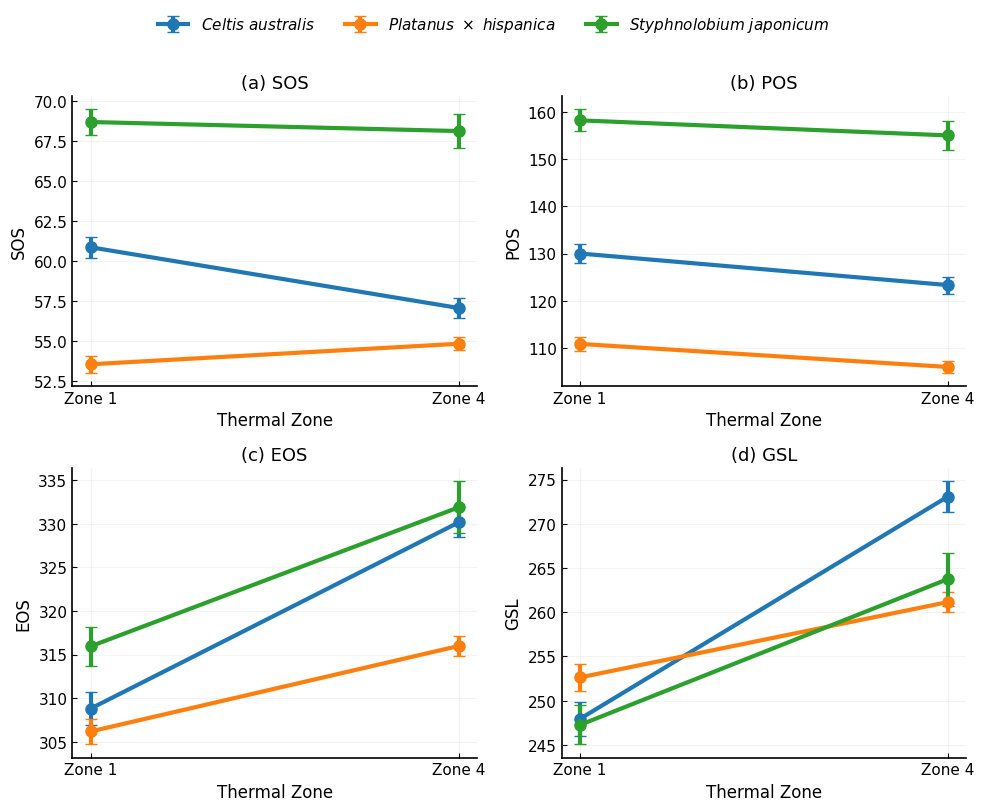

In [ ]:
# Load the individual tree LSP datasets.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

p = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Platanus_LSP_Tree.csv")
c = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Celtis_LSP_Tree.csv")
j = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Japonicum_LSP_Tree.csv")

p["Species"] = r"$\it{Platanus\ \times\ hispanica}$"
c["Species"] = r"$\it{Celtis\ australis}$"
j["Species"] = r"$\it{Styphnolobium\ japonicum}$"

# Combine the datasets.

data = pd.concat([p, c, j], ignore_index=True)

data["Species"] = data["Species"].astype("category")
data["LST_zone"] = data["LST_zone"].astype("category")

metrics = ["SOS", "POS", "EOS", "GSL"]
titles = ["(a) SOS", "(b) POS", "(c) EOS", "(d) GSL"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# Plot the interaction between species and thermal zone.

for ax, metric, title in zip(axes, metrics, titles):

    model = smf.ols(
        f"{metric} ~ C(Species) * C(LST_zone)",
        data=data,
    ).fit()

    pred = pd.DataFrame({
        "Species": np.repeat(data["Species"].cat.categories, 2),
        "LST_zone": [1, 4] * 3,
    })

    pred["Species"] = pd.Categorical(
        pred["Species"],
        categories=data["Species"].cat.categories,
    )

    pred["LST_zone"] = pd.Categorical(
        pred["LST_zone"],
        categories=data["LST_zone"].cat.categories,
    )

    prediction = model.get_prediction(pred).summary_frame(alpha=0.05)

    pred["Mean"] = prediction["mean"]
    pred["Lower"] = prediction["mean_ci_lower"]
    pred["Upper"] = prediction["mean_ci_upper"]

    for i, species in enumerate(pred["Species"].cat.categories):

        tmp = pred[pred["Species"] == species]

        ax.errorbar(
            [1, 4],
            tmp["Mean"],
            yerr=[
                tmp["Mean"] - tmp["Lower"],
                tmp["Upper"] - tmp["Mean"],
            ],
            color=colors[i],
            linewidth=3,
            marker="o",
            markersize=8,
            capsize=4,
            label=species,
        )

    ax.set_title(title, fontsize=13)
    ax.set_xticks([1, 4])
    ax.set_xticklabels(["Zone 1", "Zone 4"])
    ax.set_xlabel("Thermal Zone", fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.grid(alpha=0.15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Add a common legend.

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 1.02),
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "/content/drive/MyDrive/Colab Notebooks/Interaction_Plot_Publication.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

#Factorial Linear Model Table

In [ ]:
# Generate the publication-ready ANOVA table.

import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

metrics = ["SOS", "POS", "EOS", "GSL"]

results = []

for metric in metrics:

    model = smf.ols(
        f"{metric} ~ C(Species) * C(LST_zone)",
        data=data,
    ).fit()

    anova = anova_lm(model, typ=2)

    for effect in [
        "C(Species)",
        "C(LST_zone)",
        "C(Species):C(LST_zone)",
    ]:

        p = anova.loc[effect, "PR(>F)"]

        results.append({
            "LSP Metric": metric,
            "Effect": effect
                .replace("C(Species)", "Species")
                .replace("C(LST_zone)", "Thermal Zone")
                .replace(
                    "C(Species):C(LST_zone)",
                    "Species × Thermal Zone",
                ),
            "df": int(anova.loc[effect, "df"]),
            "F": round(anova.loc[effect, "F"], 2),
            "p-value": "<0.001" if p < 0.001 else f"{p:.3f}",
        })

# Save the ANOVA summary table.

results = pd.DataFrame(results)

print(results)

results.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/Table4_Factorial_Model.csv",
    index=False,
)

print("\nTable4_Factorial_Model.csv saved successfully.")

   LSP Metric                Effect  df        F p-value
0         SOS               Species   2   739.61  <0.001
1         SOS          Thermal Zone   1     3.95   0.047
2         SOS  Species:Thermal Zone   2    38.83  <0.001
3         POS               Species   2  1027.92  <0.001
4         POS          Thermal Zone   1    47.99  <0.001
5         POS  Species:Thermal Zone   2     1.15   0.315
6         EOS               Species   2   115.05  <0.001
7         EOS          Thermal Zone   1   389.14  <0.001
8         EOS  Species:Thermal Zone   2    25.79  <0.001
9         GSL               Species   2    21.73  <0.001
10        GSL          Thermal Zone   1   416.68  <0.001
11        GSL  Species:Thermal Zone   2    52.82  <0.001

Table4_Factorial_Model.csv saved successfully.


#Sensitivity Analysis using dynamic threshold (25%, 30%)

In [ ]:
# Perform the sensitivity analysis.

import numpy as np
import pandas as pd

thresholds = [0.20, 0.25, 0.30]

sensitivity_results = []

for threshold_fraction in thresholds:

    for _, curve in curve_results.iterrows():

        species = curve["Species"]
        zone = curve["Zone"]

        days = np.array(curve["Smooth_Days"])
        y = np.array(curve["Smooth_EVI"])

        # Calculate the dynamic threshold.
        threshold = y.min() + threshold_fraction * (y.max() - y.min())

        sos_idx = np.where(y >= threshold)[0][0]
        pos_idx = np.argmax(y)
        eos_idx = np.where(y >= threshold)[0][-1]

        sensitivity_results.append({
            "Species": species,
            "Zone": zone,
            "Threshold": int(threshold_fraction * 100),
            "SOS": days[sos_idx],
            "POS": days[pos_idx],
            "EOS": days[eos_idx],
            "GSL": days[eos_idx] - days[sos_idx],
        })

# Save the sensitivity analysis results.

sensitivity_results = pd.DataFrame(sensitivity_results)

print(sensitivity_results)

sensitivity_results.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/Sensitivity_LSP.csv",
    index=False,
)

print("\nSensitivity_LSP.csv saved successfully.")

                                   Species  Zone  Threshold        SOS  \
0   (a) $\it{Platanus\ \times\ hispanica}$     1         20  55.404504   
1   (a) $\it{Platanus\ \times\ hispanica}$     4         20  55.708924   
2             (b) $\it{Celtis\ australis}$     1         20  61.797331   
3             (b) $\it{Celtis\ australis}$     4         20  57.839867   
4      (c) $\it{Styphnolobium\ japonicum}$     1         20  66.972477   
5      (c) $\it{Styphnolobium\ japonicum}$     4         20  66.668057   
6   (a) $\it{Platanus\ \times\ hispanica}$     1         25  57.535446   
7   (a) $\it{Platanus\ \times\ hispanica}$     4         25  57.839867   
8             (b) $\it{Celtis\ australis}$     1         25  64.232694   
9             (b) $\it{Celtis\ australis}$     4         25  59.666389   
10     (c) $\it{Styphnolobium\ japonicum}$     1         25  70.929942   
11     (c) $\it{Styphnolobium\ japonicum}$     4         25  69.407840   
12  (a) $\it{Platanus\ \times\ hispani

In [ ]:
# Calculate the sensitivity relative to the 20% threshold.

import pandas as pd

baseline = (
    sensitivity_results[sensitivity_results["Threshold"] == 20]
    .rename(columns={
        "SOS": "SOS20",
        "POS": "POS20",
        "EOS": "EOS20",
        "GSL": "GSL20",
    })
    [["Species", "Zone", "SOS20", "POS20", "EOS20", "GSL20"]]
)

comparison = sensitivity_results.merge(
    baseline,
    on=["Species", "Zone"],
)

# Calculate the absolute differences.

comparison["ΔSOS"] = abs(comparison["SOS"] - comparison["SOS20"])
comparison["ΔPOS"] = abs(comparison["POS"] - comparison["POS20"])
comparison["ΔEOS"] = abs(comparison["EOS"] - comparison["EOS20"])
comparison["ΔGSL"] = abs(comparison["GSL"] - comparison["GSL20"])

comparison = comparison[comparison["Threshold"] != 20]

# Summarize the sensitivity analysis.

summary = (
    comparison
    .groupby("Threshold")[["ΔSOS", "ΔPOS", "ΔEOS", "ΔGSL"]]
    .mean()
    .round(2)
)

print(summary)

summary.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/Table5_Sensitivity.csv",
)

print("\nTable5_Sensitivity.csv saved successfully.")

           ΔSOS  ΔPOS   ΔEOS   ΔGSL
Threshold                          
25         2.54   0.0  12.68  15.22
30         4.67   0.0  23.69  28.36

Table5_Sensitivity.csv saved successfully.


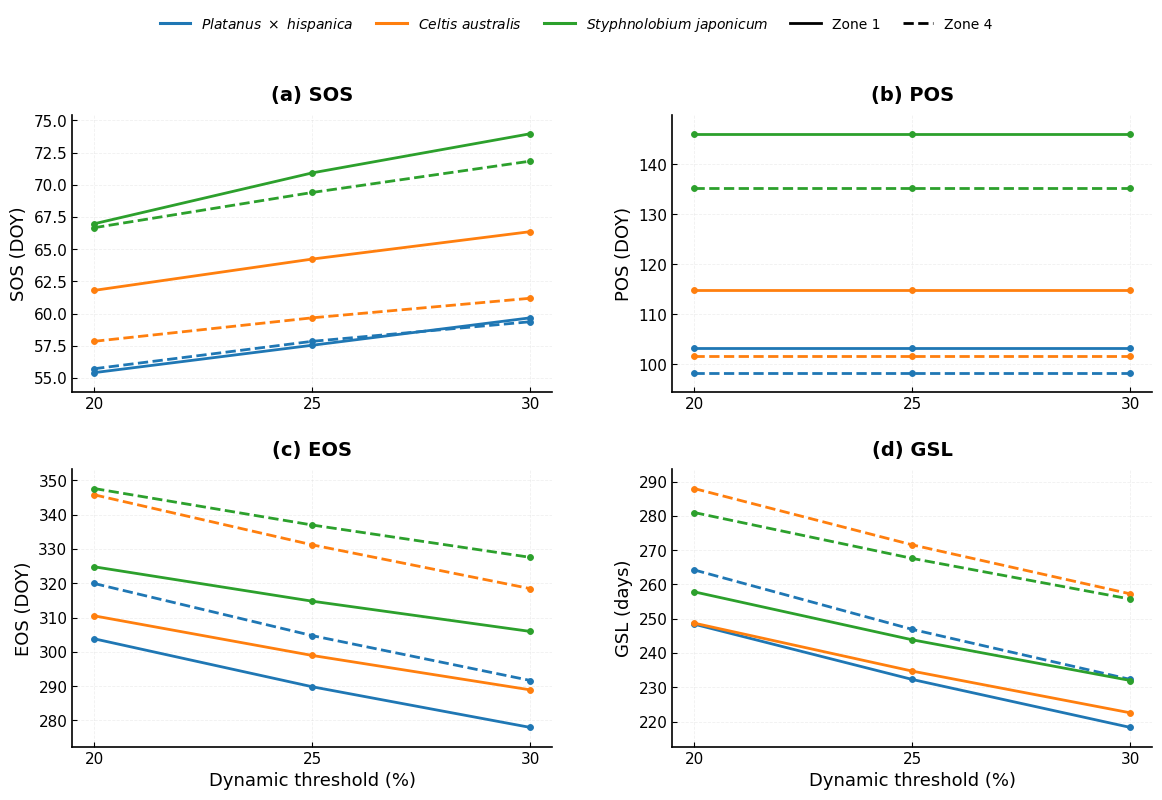

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Prepare the sensitivity analysis data.

df = sensitivity_results.copy()

metrics = ["SOS", "POS", "EOS", "GSL"]
titles = ["(a) SOS", "(b) POS", "(c) EOS", "(d) GSL"]

species_order = list(df["Species"].unique())

colors = {
    species_order[0]: "#1f77b4",
    species_order[1]: "#ff7f0e",
    species_order[2]: "#2ca02c",
}

# Configure the publication-style figure.

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Plot the sensitivity analysis.

for ax, metric, title in zip(axes, metrics, titles):

    for species in species_order:

        for zone in [1, 4]:

            tmp = (
                df[
                    (df["Species"] == species)
                    & (df["Zone"] == zone)
                ]
                .sort_values("Threshold")
            )

            ax.plot(
                tmp["Threshold"],
                tmp[metric],
                color=colors[species],
                linestyle="-" if zone == 1 else "--",
                linewidth=2.0,
                marker="o",
                markersize=4.2,
                markeredgewidth=0.7,
            )

    ax.set_title(title, pad=10, fontweight="bold")
    ax.set_xticks([20, 25, 30])

    ax.set_xlabel(
        "Dynamic threshold (%)"
        if metric in ["EOS", "GSL"]
        else ""
    )

    ax.set_ylabel(
        "GSL (days)"
        if metric == "GSL"
        else f"{metric} (DOY)"
    )

    ax.grid(
        linestyle="--",
        linewidth=0.6,
        alpha=0.18,
    )

    ax.set_axisbelow(True)
    ax.margins(y=0.08)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

# Add the figure legend.

legend_handles = [
    Line2D(
        [0], [0],
        color="#1f77b4",
        lw=2.2,
        label=r"$\it{Platanus\ \times\ hispanica}$",
    ),
    Line2D(
        [0], [0],
        color="#ff7f0e",
        lw=2.2,
        label=r"$\it{Celtis\ australis}$",
    ),
    Line2D(
        [0], [0],
        color="#2ca02c",
        lw=2.2,
        label=r"$\it{Styphnolobium\ japonicum}$",
    ),
    Line2D(
        [0], [0],
        color="black",
        lw=2,
        linestyle="-",
        label="Zone 1",
    ),
    Line2D(
        [0], [0],
        color="black",
        lw=2,
        linestyle="--",
        label="Zone 4",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False,
    fontsize=10,
    handlelength=2.2,
    columnspacing=1.6,
)

# Save the figure.

plt.subplots_adjust(
    top=0.88,
    bottom=0.09,
    left=0.08,
    right=0.98,
    hspace=0.28,
    wspace=0.25,
)

plt.savefig(
    "Figure9_Final_Publication.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()